      RELATÓRIO DE QUALIDADE DE DADOS     
      Arquivo: ../Data/Gold/games_dataset_cleaned.csv      

1. COMPLETUDE DOS DADOS
------------------------------------------------------------
Dimensões do DataFrame: 29681 linhas x 24 colunas
Células Totais: 712,344
Células Ausentes: 22,211
Completude Geral: 96.88%

Completude por coluna (Top 5 colunas com mais dados ausentes):
| Coluna          | % Ausente   | Completude   |
|:----------------|:------------|:-------------|
| tags            | 52.2287     | 47.7713      |
| 2categoria      | 22.2836     | 77.7164      |
| published_store | 0.32007     | 99.6799      |

2. UNICIDADE DOS DADOS
------------------------------------------------------------
Duplicatas de LINHAS INTEIRAS: 0 (Unicidade: 100.00%)
Duplicatas de 'appid' (Chave): 0 (Unicidade: 100.00%)

3. CONSISTÊNCIA INTERNA DOS DADOS
------------------------------------------------------------
Linhas onde 'total_reviews' != ('positive' + 'negative'): 0

4. VALIDADE DOS DADOS (Range

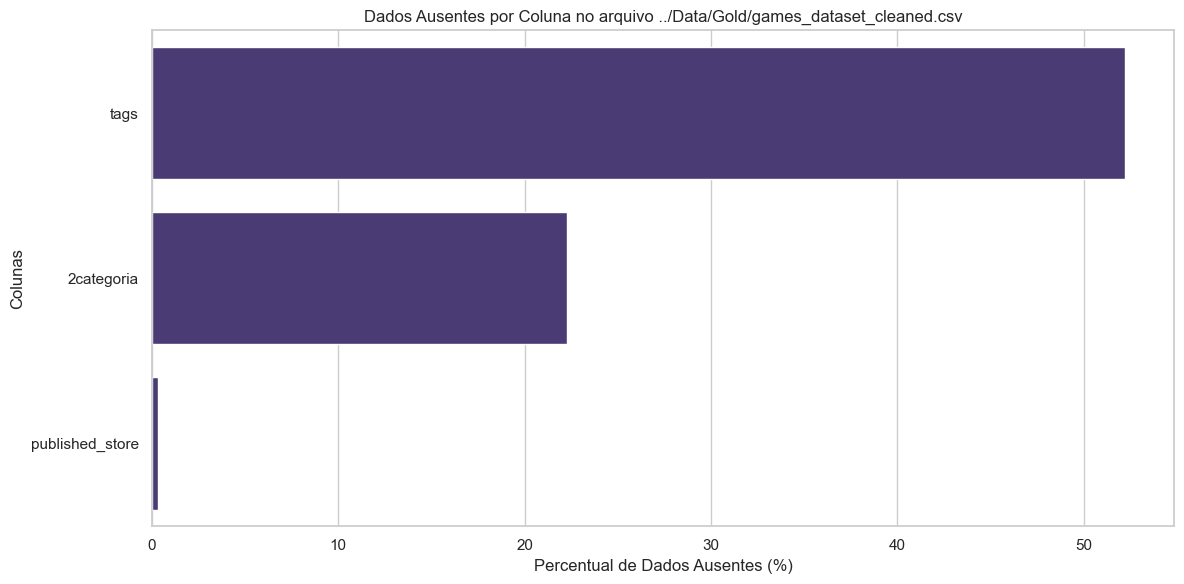


      SCORE GERAL DE QUALIDADE (Baseado no seu script)     
Completude Geral: 96.88%
Unicidade (appid): 100.00%
Score Final: 98.44%
Classificação: EXCELENTE


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

caminho = '../Data/Gold/games_dataset_cleaned.csv'

def a(file_path):

    df = pd.read_csv(file_path)


    # Definindo um estilo visual mais moderno com Seaborn
    sns.set_theme(style="whitegrid", palette="viridis")

    print("="*60)
    print("      RELATÓRIO DE QUALIDADE DE DADOS     ")
    print(f"      Arquivo: {file_path}      ")
    print("="*60)
    
    # ==========================================
    # 1. COMPLETUDE
    # ==========================================
    print("\n1. COMPLETUDE DOS DADOS")
    print("-" * 60)
    
    total_celulas = np.prod(df.shape)
    celulas_ausentes = df.isnull().sum().sum()
    celulas_preenchidas = total_celulas - celulas_ausentes
    completude_geral = (celulas_preenchidas / total_celulas) * 100
    
    print(f"Dimensões do DataFrame: {df.shape[0]} linhas x {df.shape[1]} colunas")
    print(f"Células Totais: {total_celulas:,}")
    print(f"Células Ausentes: {celulas_ausentes:,}")
    print(f"Completude Geral: {completude_geral:.2f}%")

    print("\nCompletude por coluna (Top 5 colunas com mais dados ausentes):")
    completude_colunas = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    # Filtra para mostrar apenas colunas com dados ausentes
    completude_colunas_ausentes = completude_colunas[completude_colunas > 0]
    
    if completude_colunas_ausentes.empty:
        print("Nenhuma coluna com dados ausentes. Perfeito!")
    else:
        missing_df = pd.DataFrame({
            'Coluna': completude_colunas_ausentes.index,
            '% Ausente': completude_colunas_ausentes.values,
            'Completude': (100 - completude_colunas_ausentes.values)
        })
        # Imprime como markdown para formatação de tabela
        print(missing_df.to_markdown(index=False, numalign="left", stralign="left"))

    # ==========================================
    # 2. UNICIDADE
    # ==========================================
    print("\n2. UNICIDADE DOS DADOS")
    print("-" * 60)
    
    duplicatas_linhas = df.duplicated().sum()
    unicidade_linhas = ((len(df) - duplicatas_linhas) / len(df)) * 100
    
    duplicatas_appid = df.duplicated(subset=['appid']).sum()
    unicidade_appid = ((len(df) - duplicatas_appid) / len(df)) * 100
    
    print(f"Duplicatas de LINHAS INTEIRAS: {duplicatas_linhas} (Unicidade: {unicidade_linhas:.2f}%)")
    print(f"Duplicatas de 'appid' (Chave): {duplicatas_appid} (Unicidade: {unicidade_appid:.2f}%)")

    # ==========================================
    # 3. CONSISTÊNCIA
    # ==========================================
    print("\n3. CONSISTÊNCIA INTERNA DOS DADOS")
    print("-" * 60)
    
    if all(col in df.columns for col in ['total_reviews', 'positive', 'negative']):
        inconsistencias_reviews = (df['total_reviews'] != (df['positive'] + df['negative'])).sum()
        print(f"Linhas onde 'total_reviews' != ('positive' + 'negative'): {inconsistencias_reviews}")
    else:
        print("Colunas de review não encontradas para checagem de consistência.")

    # ==========================================
    # 4. VALIDADE
    # ==========================================
    print("\n4. VALIDADE DOS DADOS (Ranges)")
    print("-" * 60)
    
    if 'price' in df.columns:
        precos_invalidos = (df['price'] < 0).sum()
        print(f"Registros com 'price' negativo: {precos_invalidos}")
    
    if 'discount' in df.columns:
        descontos_invalidos = ((df['discount'] < 0) | (df['discount'] > 100)).sum()
        print(f"Registros com 'discount' fora do range [0, 100]: {descontos_invalidos}")

    # ==========================================
    # 5. VISUALIZAÇÃO DE DADOS AUSENTES
    # ==========================================
    print("\n5. VISUALIZAÇÃO DE DADOS AUSENTES")
    print("-" * 60)
    
    plt.figure(figsize=(12, 6))
    
    if completude_colunas_ausentes.empty:
        print("Gráfico não gerado (sem dados ausentes).")
    else:
        # Plotando apenas as colunas com dados ausentes
        sns.barplot(
            x=completude_colunas_ausentes.values, 
            y=completude_colunas_ausentes.index,
        )
        plt.xlabel('Percentual de Dados Ausentes (%)')
        plt.ylabel('Colunas')
        plt.title(f'Dados Ausentes por Coluna no arquivo {file_path}')
        plt.tight_layout()

    # ==========================================
    # SCORE FINAL
    # ==========================================
    print("\n" + "="*60)
    print("      SCORE GERAL DE QUALIDADE DE DADOS     ")
    print("="*60)
    
    score_final = (completude_geral + unicidade_appid) / 2
    
    print(f"Completude Geral: {completude_geral:.2f}%")
    print(f"Unicidade (appid): {unicidade_appid:.2f}%")
    print(f"Score Final: {score_final:.2f}%")

    if score_final >= 90:
        print("Classificação: EXCELENTE")
    elif score_final >= 80:
        print("Classificação: BOM")
    elif score_final >= 70:
        print("Classificação: REGULAR")
    else:
        print("Classificação: NECESSITA MELHORIAS")
a(caminho)